In [ ]:
import zipfile
import pandas as pd
import os

zip_path = "/content/English.zip"
extract_folder = "/content/extracted"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

all_dfs = []

for root, dirs, files in os.walk(extract_folder):

    for file in files:

        if file.endswith(".xlsx") and "_Bianca" in file:

            file_path = os.path.join(root, file)

            adjective = file.split("_Bianca")[0]

            df = pd.read_excel(file_path)
            df["adjective"] = adjective

            all_dfs.append(df)

combined_df = pd.concat(all_dfs, ignore_index=True)

combined_df.to_excel(
    "/content/combined_Bianca.xlsx",
    index=False
)

print(combined_df.head())

              file Domain Gender  sent_index  token_id token_form token_lemma  \
0  Art12_en.conllu    Art      M          35        14  different   different   
1  Art12_en.conllu    Art      M          60        43  different   different   
2  Art13_en.conllu    Art      M          30        10  different   different   
3  Art14_en.conllu    Art      M          44         6  different   different   
4  Art14_en.conllu    Art      M          75        12  different   different   

                                            sentence EN_Evaluative?  \
0  And now it 's 2010 , and there are 99 heroes f...     Evaluative   
1  And he controls them from the top down -- wher...     Evaluative   
2  Fair enough . But I wanted interviews that wer...     Evaluative   
3  It 's about mappings between different percept...     Evaluative   
4  And so I 've been beginning , with a variety o...     Evaluative   

  EN_Attitude_type de_aligned_forms de_aligned_lemmas  \
0     Appreciation           

# Positive vs. Negative

In [ ]:
!pip install pandas openpyxl spacy

In [40]:
import pandas as pd
import spacy
from pathlib import Path

# Load English model
nlp = spacy.load("en_core_web_sm")

INPUT_FILE = "/content/combined_Bianca.xlsx"
SENTENCE_COL = "sentence"
ADJ_COL = "adjective"  # change if your column name differs

NEGATION_WORDS = {
    "not",
    "never",
    "no",
    "n't"
}


"""

NOTE:I've checked all sentences with these phrases and negators but it doesnt have any occurance of this.

NEGATION_PHRASES = {
    "no longer",
    "by no means",
    "in no way",
    "under no circumstances",
    "on no account"
}

BORDERLINE_NEGATORS = {
    "hardly",
    "barely",
    "scarcely",
    "rarely",
    "seldom"
}
"""

def is_negated_adjective(sentence, adjective):
    """
    Detect whether the target adjective is negated.
    Returns:
        (True/False, negation_type)
    """

    if pd.isna(sentence) or pd.isna(adjective):
        return False, None

    doc = nlp(str(sentence))
    adjective = str(adjective).lower()

    for token in doc:

        if token.lemma_.lower() != adjective:
            continue

        # Direct dependency negation
        for child in token.children:
            if child.dep_ == "neg":
                return True, child.text

        # Negation attached to adjective head
        if token.head:
            for child in token.head.children:
                if child.dep_ == "neg":
                    return True, child.text

        # Common negation words nearby
        window = doc[max(0, token.i - 4): min(len(doc), token.i + 5)]

        for nearby in window:
            if nearby.lower_ in NEGATION_WORDS:
                return True, nearby.text

        # "no longer"
        text = sentence.lower()
        if "no longer" in text:
            return True, "no longer"

    return False, None


def split_positive_negative(df):

    negative_rows = []
    positive_rows = []

    for _, row in df.iterrows():

        sentence = row[SENTENCE_COL]
        adjective = row[ADJ_COL]

        negated, neg_type = is_negated_adjective(
            sentence,
            adjective
        )

        row_copy = row.copy()

        if negated:
            row_copy["negation_type"] = neg_type
            negative_rows.append(row_copy)
        else:
            positive_rows.append(row_copy)

    negative_df = pd.DataFrame(negative_rows)
    positive_df = pd.DataFrame(positive_rows)

    return positive_df, negative_df


def main():

    df = pd.read_excel(INPUT_FILE)

    positive_df, negative_df = split_positive_negative(df)

    positive_df.to_excel(
        "positive.xlsx",
        index=False
    )

    negative_df.to_excel(
        "negative.xlsx",
        index=False
    )

    print(f"Positive rows: {len(positive_df)}")
    print(f"Negative rows: {len(negative_df)}")


if __name__ == "__main__":
    main()

Positive rows: 2767
Negative rows: 222


# Evaluative vs. Non-Evaluative

In [42]:
df = pd.read_excel("/content/combined_Bianca.xlsx")

In [43]:
df.columns = (
    df.columns
    .str.replace("?", "", regex=False)
    .str.strip()
    .str.replace(" ", "_")
)

In [45]:
cols = ["EN_Evaluative", "DE_Evaluative"]

for c in cols:
    df[c] = (
        df[c]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace("nan", pd.NA)
    )

### Per adjective frequencies:

* EN_eval
* EN_non_eval
* EN_eval_not_speaker
* DE equivalents

In [88]:
table_a = (
    df.groupby("adjective")
      .agg(
          total_occurrences=("adjective", "size"),

          EN_eval=("EN_Evaluative",
                   lambda x: (x == "evaluative").sum()),

          EN_non_eval=("EN_Evaluative",
                       lambda x: (x == "non-evaluative").sum()),

          EN_eval_not_speaker=("EN_Evaluative",
                               lambda x: (x == "evaluative-not_speaker").sum()),

          DE_eval=("DE_Evaluative",
                   lambda x: (x == "evaluative").sum()),

          DE_non_eval=("DE_Evaluative",
                       lambda x: (x == "non-evaluative").sum()),

          DE_eval_not_speaker=("DE_Evaluative",
                               lambda x: (x == "evaluative-not_speaker").sum())
      )
      .reset_index()
)
table_a

,adjective,total_occurrences,EN_eval,EN_non_eval,EN_eval_not_speaker,DE_eval,DE_non_eval,DE_eval_not_speaker
0,amazing,123,120,0,3,118,2,3
1,bad,251,201,8,42,194,17,39
2,beautiful,73,61,2,9,60,3,9
3,creative,56,37,12,7,36,13,7
4,different,394,378,1,15,355,21,15
5,difficult,65,56,0,8,57,1,6
6,good,848,676,111,59,662,125,56
7,happy,121,39,6,76,40,9,71
8,important,248,222,1,25,216,6,26
9,incredible,53,53,0,0,51,1,0


Overall EN evaluativity distribution.

In [89]:
table_b = (
    df["EN_Evaluative"]
    .value_counts(dropna=False)
    .rename_axis("EN_Evaluative_Status")
    .reset_index(name="Count")
)

table_b["Percentage"] = (
    table_b["Count"]
    / table_b["Count"].sum()
    * 100
).round(2)

### Overall DE evaluativity distribution.

In [60]:
table_b_de = (
    df["DE_Evaluative"]
    .value_counts(dropna=False)
    .rename_axis("DE_Evaluative_Status")
    .reset_index(name="Count")
)

table_b_de["Percentage"] = (
    table_b_de["Count"]
    / table_b_de["Count"].sum()
    * 100
).round(2)

table_b_de

,DE_Evaluative_Status,Count,Percentage
0,evaluative,2345,78.45
1,non-evaluative,327,10.94
2,evaluative-not_speaker,294,9.84
3,<NA>,17,0.57
4,uncertain,6,0.20


In [75]:
eval_df = df[
    df["EN_Evaluative"] != "non-evaluative"
]

### Overall English Attitude types.

In [76]:
table_c = (
    eval_df["EN_Attitude_type"]
    .value_counts()
    .rename_axis("Attitude")
    .reset_index(name="Count")
)

table_c["Percentage"] = (
    table_c["Count"]
    / table_c["Count"].sum()
    * 100
).round(2)

table_c

,Attitude,Count,Percentage
0,Appreciation,2178,78.88
1,Judgement,438,15.86
2,Affect,128,4.64
3,Uncertain,17,0.62


### Attitude × evaluativity source (speaker vs not-speaker).

In [70]:
table_c1 = pd.crosstab(
    eval_df["EN_Attitude_type"],
    eval_df["EN_Evaluative"]
)

table_c1

EN_Evaluative,evaluative,evaluative-not_speaker
EN_Attitude_type,,
Affect,38,90
Appreciation,2018,160
Judgement,377,61
Uncertain,17,0


### Overall Attitude Distribution

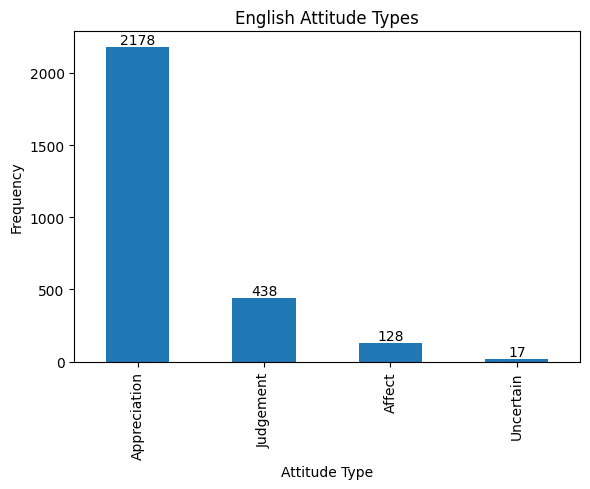

In [83]:
import matplotlib.pyplot as plt

counts = (
    eval_df["EN_Attitude_type"]
    .value_counts()
)

plt.figure(figsize=(6, 5))

counts.plot(kind="bar")

#adding count values on top of the bars
for i, v in enumerate(counts):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.ylabel("Frequency")
plt.xlabel("Attitude Type")
plt.title("English Attitude Types")

plt.tight_layout()
plt.savefig("graph1_attitude_distribution.png",dpi = 1200)

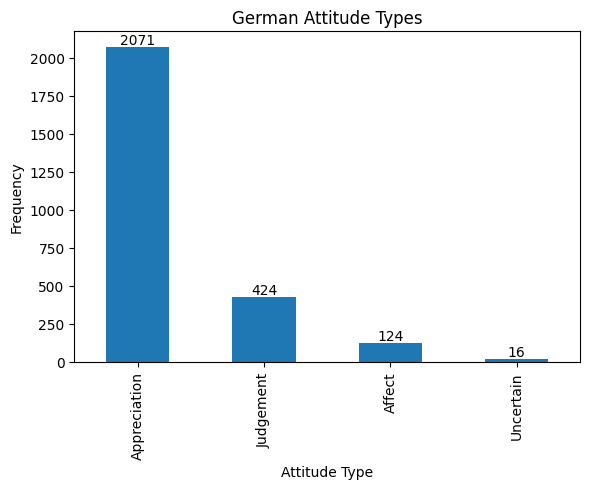

In [84]:
import matplotlib.pyplot as plt

counts = (
    eval_df["DE_Attitude_type"]
    .value_counts()
)

plt.figure(figsize=(6, 5))

counts.plot(kind="bar")

#adding count values on top of the bars
for i, v in enumerate(counts):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.ylabel("Frequency")
plt.xlabel("Attitude Type")
plt.title("German Attitude Types")

plt.tight_layout()
plt.savefig("graph1_attitude_distribution_DE.png",dpi = 1200)

### Attitude Distribution per Adjective

In [77]:
attitude_by_adj = pd.crosstab(
    eval_df["adjective"],
    eval_df["EN_Attitude_type"]
)

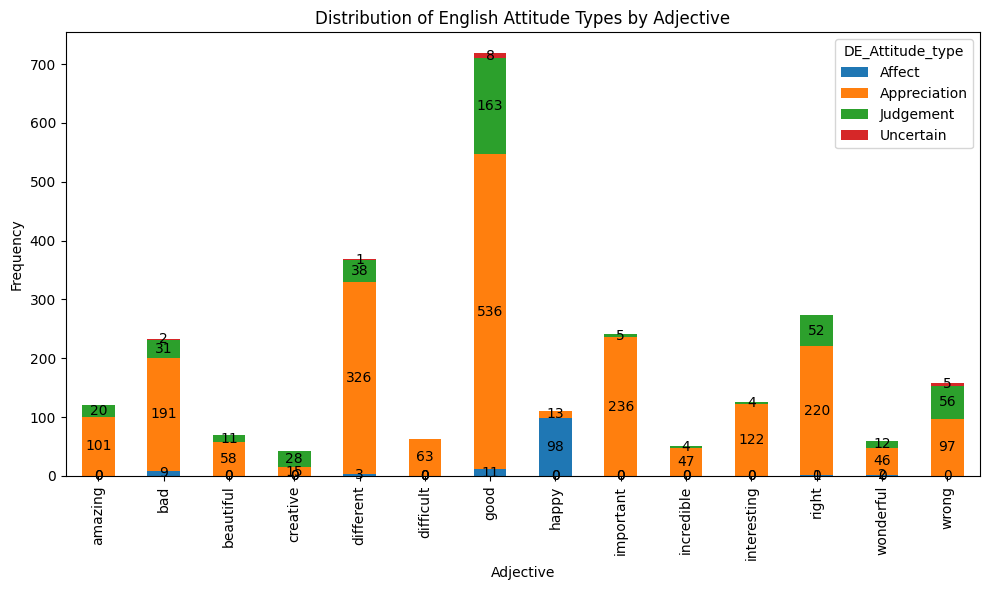

In [92]:
ax = attitude_by_adj.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.ylabel("Frequency")
plt.xlabel("Adjective")
plt.title("Distribution of English Attitude Types by Adjective")

for container in ax.containers:
    ax.bar_label(
        container,
        label_type="center",   # puts number inside bar
        fontsize=10,
        color="black"
    )

plt.tight_layout()
plt.savefig("graph2_attitude_by_adjective.png", dpi=1200)

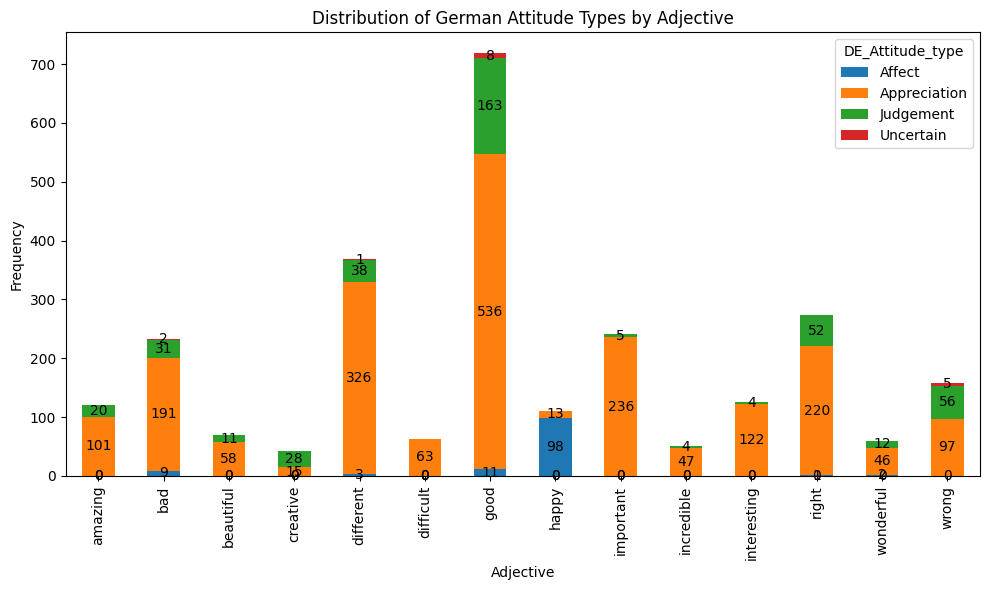

In [93]:
attitude_by_adj = pd.crosstab(
    eval_df["adjective"],
    eval_df["DE_Attitude_type"]
)

ax = attitude_by_adj.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.ylabel("Frequency")
plt.xlabel("Adjective")
plt.title("Distribution of German Attitude Types by Adjective")

for container in ax.containers:
    ax.bar_label(
        container,
        label_type="center",   # puts number inside bar
        fontsize=10,
        color="black"
    )

plt.tight_layout()
plt.savefig("graph2_attitude_by_adjective_DE.png", dpi=1200)

In [95]:
df

,file,Domain,Gender,sent_index,token_id,token_form,token_lemma,sentence,EN_Evaluative,EN_Attitude_type,...,de_aligned_lemmas,de_sentence,DE_Evaluative,DE_Attitude_type,Translation_strategy,Translationese_effect,adjective,correction_lemma,opinion_match,EN_Eval_Binary
0,Art12_en.conllu,Art,M,35,14,different,different,"And now it 's 2010 , and there are 99 heroes f...",evaluative,Appreciation,...,NaN,Jetzt ist 2010 und es gibt 99 Helden aus 99 Lä...,non-evaluative,NaN,Alteration,Implicitation,different,NaN,False,evaluative
1,Art12_en.conllu,Art,M,60,43,different,different,And he controls them from the top down -- wher...,evaluative,Appreciation,...,NaN,Er kontrolliert sie von oben herab . Als sie s...,non-evaluative,NaN,Alteration,Implicitation,different,NaN,False,evaluative
2,Art13_en.conllu,Art,M,30,10,different,different,Fair enough . But I wanted interviews that wer...,evaluative,Appreciation,...,anders,"Schön und gut , aber ich wollte Interviews , d...",evaluative,Appreciation,Equivalence,NaN,different,NaN,True,evaluative
3,Art14_en.conllu,Art,M,44,6,different,different,It 's about mappings between different percept...,evaluative,Appreciation,...,verschieden,Es geht dabei um Verbindungen zwischen verschi...,evaluative,Appreciation,Equivalence,NaN,different,NaN,True,evaluative
4,Art14_en.conllu,Art,M,75,12,different,different,"And so I 've been beginning , with a variety o...",evaluative,Appreciation,...,verschieden,"Ich habe also angefangen , mit vielen verschie...",evaluative,Appreciation,Equivalence,NaN,different,NaN,True,evaluative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2984,Tech23_en.conllu,Tech,M,106,82,creative,creative,It would be really great if you did n't let pe...,evaluative-not_speaker,Judgement,...,kreativ,"Es wäre wirklich großartig , wenn wir aufhörte...",evaluative-not_speaker,Judgement,Equivalence,NaN,creative,NaN,True,evaluative
2985,Tech3_en.conllu,Tech,F,55,6,creative,creative,We did n't do the creative or critical thinkin...,evaluative,Appreciation,...,kritisch,Wir haben nicht kritisch und kreativ genug nac...,evaluative,Judgement,Equivalence,NaN,creative,kreativ,True,evaluative
2986,Tech9_en.conllu,Tech,F,22,31,creative,creative,What I was trying to do with tuning these horm...,non-evaluative,NaN,...,kreativ,Ich wollte eines erreichen mit dem Abstimmen d...,non-evaluative,NaN,NaN,NaN,creative,NaN,True,non-evaluative
2987,Tech9_en.conllu,Tech,F,28,14,creative,creative,"Mental images , for most of us , are central i...",non-evaluative,NaN,...,kreativ,"Mentale Bilder , für die meisten unter uns , s...",non-evaluative,NaN,NaN,NaN,creative,NaN,True,non-evaluative


# Attitude in EN and DE

In [102]:
table_attitude = pd.crosstab(
    eval_df["EN_Attitude_type"],
    eval_df["DE_Attitude_type"]
)

table_attitude

DE_Attitude_type,Affect,Appreciation,Judgement,Uncertain
EN_Attitude_type,,,,
Affect,122,0,0,0
Appreciation,2,2059,14,0
Judgement,0,11,410,0
Uncertain,0,1,0,16


In [97]:
df["attitude_match"] = (
    df["EN_Attitude_type"] == df["DE_Attitude_type"]
)

total = len(df)

mismatch_count = (~df["attitude_match"]).sum()
match_count = df["attitude_match"].sum()

mismatch_rate = mismatch_count / total
match_rate = match_count / total

print("Mismatch rate:", round(mismatch_rate, 4))
print("Match rate:", round(match_rate, 4))

Mismatch rate: 0.1268
Match rate: 0.8732


## Chi-square test (association test)
Is EN Attitude independent of DE Attitude?
* p < 0.05 → EN attitude significantly associated with DE attitude (translation is not random)
* p ≥ 0.05 → no strong evidence of systematic shift

In [103]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(table_attitude)

print("Chi-square:", chi2)
print("df:", dof)
print("p-value:", p)

#translation is not random

Chi-square: 7519.520763577718
df: 9
p-value: 0.0



## Effect size
* ~0.1 = small shift
* ~0.3 = moderate shift
* ~0.5+ = strong systematic translation restructuring

In [106]:
import numpy as np

n = table_attitude.to_numpy().sum()

cramers_v = np.sqrt(
    chi2 / (n * (min(table_attitude.shape) - 1))
)

print("Cramér's V:", cramers_v)

Cramér's V: 0.9753132949073275


##Loglinear

Poisson regression approximation of loglinear models


In [116]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ----------------------------
# 1. Clean data
# ----------------------------
df_ll = df.dropna(
    subset=[
        "EN_Attitude_type",
        "DE_Attitude_type",
        "Translation_strategy",
        "Translationese_effect",
        "Gender",
        "Domain"
    ]
).copy()

# ----------------------------
# 2. Create frequency table
# ----------------------------
freq = (
    df_ll
    .groupby([
        "EN_Attitude_type",
        "DE_Attitude_type",
        "Translation_strategy",
        "Translationese_effect",
        "Gender",
        "Domain"
    ])
    .size()
    .reset_index(name="freq")
)

# ----------------------------
# 3. Model 1 (main effects)
# ----------------------------
model_1 = smf.glm(
    formula="""
        freq ~ EN_Attitude_type
             + DE_Attitude_type
             + Translation_strategy
             + Translationese_effect
             + Gender
             + Domain
    """,
    data=freq,
    family=sm.families.Poisson()
).fit()

print("\n===== MODEL 1 SUMMARY =====\n")
print(model_1.summary())

# ----------------------------
# 4. Model 2 (interactions)
# ----------------------------
model_2 = smf.glm(
    formula="""
        freq ~ EN_Attitude_type * DE_Attitude_type
             + EN_Attitude_type * Translation_strategy
             + DE_Attitude_type * Translation_strategy
             + Translation_strategy * Translationese_effect
             + Gender
             + Domain
    """,
    data=freq,
    family=sm.families.Poisson()
).fit()

print("\n===== MODEL 2 SUMMARY =====\n")
print(model_2.summary())

# ----------------------------
# 5. Likelihood Ratio Test (correct way)
# ----------------------------
import scipy.stats as stats

lr_stat = 2 * (model_2.llf - model_1.llf)
df_diff = model_2.df_model - model_1.df_model

p_value = stats.chi2.sf(lr_stat, df_diff)

print("\n===== LR TEST =====")
print("Likelihood Ratio:", lr_stat)
print("df difference:", df_diff)
print("p-value:", p_value)

# ----------------------------
# 6. Overdispersion check (important!)
# ----------------------------
dispersion = model_1.deviance / model_1.df_resid

print("\n===== OVERDISPERSION CHECK =====")
print("Dispersion (deviance / df_resid):", dispersion)

if dispersion > 2:
    print("Strong overdispersion detected → consider Negative Binomial model")
else:
    print("Poisson assumption is reasonably OK")


===== MODEL 1 SUMMARY =====

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   freq   No. Observations:                   64
Model:                            GLM   Df Residuals:                       46
Model Family:                 Poisson   Df Model:                           17
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -107.47
Date:                Sun, 31 May 2026   Deviance:                       39.127
Time:                        22:47:02   Pearson chi2:                     40.8
No. Iterations:                     5   Pseudo R-squ. (CS):             0.4924
Covariance Type:            nonrobust                                         
                                             coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------